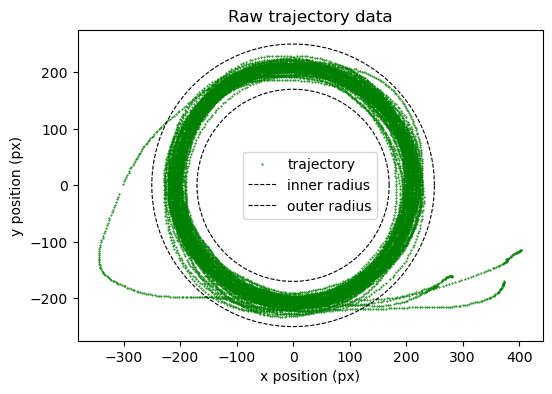

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ====================================================
# FILE PATHS
# ====================================================

RAW_FILE    = "../data/001MoDe_R1.csv" #continuous mouse trajectory
MARKER_FILE = "../data/001MoDe_R1.marker.csv" #event timestamps (DoRecord / DoPause)

# ====================================================
# PARSING METADATA FROM FIRST LINE OF RAW FILE
# ====================================================
with open(RAW_FILE, "r") as f:
    metadata_line = f.readline().strip()

# Metadata is written as "key value;key value;..."
metadata_entries = metadata_line.split(";")

# Initialize fields
center_x = 0.0
center_y = 0.0
radius_inner = 0.0
radius_outer = 0.0

# Extract numeric values from metadata
for entry in metadata_entries:
    tokens = entry.split()
    if len(tokens) != 2:
        continue
    key, val = tokens
    if key == "centerX":
        center_x = float(val)
    elif key == "centerY":
        center_y = float(val)
    elif key == "internalRadius":
        radius_inner = float(val)
    elif key == "externalRadius":
        radius_outer = float(val)

# important ! If numeries values are hardcoded (eg, "center_x = 552") 
# it won't carry over if another file w/ different metadata is used.


# ====================================================
# PARSE EVENT MARKERS (DoRecord / DoPause)
# ====================================================
record_starts = []
record_stops  = []

with open(MARKER_FILE, "r") as f:
    for line in f:
        if "," not in line:
            continue
        
        parts = line.strip().split(",") # e.g., ["#Marker", "123456", "DoRecord"]
        if len(parts) < 3: 
            continue
        
        # parts[1] = timestamp, we keep only pure integers
        ts_str = parts[1]
        if not ts_str.isdigit():
            continue
        
        timestamp = int(ts_str) # in milliseconds
        event     = parts[2] # e.g., "DoRecord" or "DoPause"
        
        if "DoRecord" in event:
            record_starts.append(timestamp)
        elif "DoPause" in event:
            record_stops.append(timestamp)

record_starts = np.array(record_starts)
record_stops  = np.array(record_stops)

# ====================================================
# LOAD TRAJECTORY DATA 
# ====================================================
# Line structure after skip:
# time, mouseX, mouseY, inTargetFlag
raw_data = np.genfromtxt(RAW_FILE, delimiter=",", skip_header=4) #skip the metadata + 3 header lines
time_all, mouse_x_all, mouse_y_all, inside_target_all = raw_data.T

# Recenter into target coordinate system
x_all = mouse_x_all - center_x
y_all = -(mouse_y_all - center_y)  # flip Y-axis, otherwise upside-down

# ====================================================
# KEEP ONLY VALID RECORDING SEGMENTS
# ====================================================
valid_mask = np.zeros_like(time_all, dtype=bool) 

for start, stop in zip(record_starts, record_stops):
    # -30 ms ensures the segment is not abruptly cut, gotta try w/ some margin
    valid_mask |= (time_all >= (start - 30)) & (time_all <= stop)

x_valid = x_all[valid_mask] #filtered x positions
y_valid = y_all[valid_mask] #filtered y positions
t_valid = time_all[valid_mask] #filtered timestamps

# ====================================================
# DONUT (INNER + OUTER CIRCLE, THE ANNULUS)
# ====================================================
theta = np.linspace(0, 2*np.pi, 512) #angle parameterization ! hard coded !
circle_inner_x = radius_inner * np.cos(theta) 
circle_inner_y = radius_inner * np.sin(theta)
circle_outer_x = radius_outer * np.cos(theta)
circle_outer_y = radius_outer * np.sin(theta)

# ====================================================
# PLOT TRAJECTORY + DONUT
# ====================================================
plt.figure(figsize=(6, 6))

# Raw movement
plt.plot(x_valid, y_valid, ".", color="green", markersize=1, label="trajectory")

# Donut boundaries
plt.plot(circle_inner_x, circle_inner_y, "k--", lw=0.8, label="inner radius")
plt.plot(circle_outer_x, circle_outer_y, "k--", lw=0.8, label="outer radius")

plt.gca().set_aspect("equal")
plt.xlabel("x position (px)")
plt.ylabel("y position (px)")
plt.title("Raw trajectory data")
plt.legend()
plt.show()

# ====================================================
# TODO
# ====================================================
# fix plotting (bigger dots to fill the donut ?) / add trajectory/ add colors


In [ ]:
import os
print(os.getcwd())

c:\Users\morga\Desktop\IEAP\Modeling\GROUP PROJECT\Circular-task-assignement-Savona-Singer-Virolan\notebooks


In [3]:
import os

print(os.path.exists(RAW_FILE))
print(os.path.exists(MARKER_FILE))


False
False
